# Task 1: Steepest-Ascent Hill Climbing for Discrete Optimization

Start State: -6

Steepest-Ascent Result: -2
Objective Value: 32

First-Choice Result: -2
Objective Value: 32


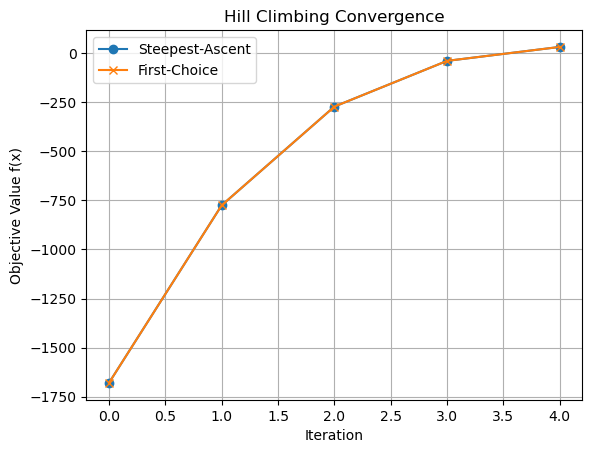


Analysis:
Hill climbing searches locally by comparing neighboring states.
If a state has no better neighbors, the algorithm stops.

Local Optima:
The function may contain multiple peaks. Hill climbing can stop at a local maximum instead of the global maximum depending on the start state.

Algorithm Differences:
Steepest-Ascent evaluates ALL neighbors and chooses the best.
First-Choice randomly checks neighbors and moves to the first improvement.
First-Choice is usually faster but may reach different solutions.


In [1]:
import random
import matplotlib.pyplot as plt

# Objective Function
def f(x):
    return -x**4 + 4*x**3 + 10*x**2 - 20*x


# Generate neighbors
def generate_neighbors(x):
    neighbors = []
    
    if x - 1 >= -10:
        neighbors.append(x - 1)
    if x + 1 <= 10:
        neighbors.append(x + 1)
        
    return neighbors


# --------------------------------
# Steepest-Ascent Hill Climbing
# --------------------------------
def steepest_hill_climbing(start):

    current = start
    iterations = []
    values = []
    step = 0

    while True:

        iterations.append(step)
        values.append(f(current))

        neighbors = generate_neighbors(current)

        best_neighbor = current
        best_value = f(current)

        for n in neighbors:
            if f(n) > best_value:
                best_neighbor = n
                best_value = f(n)

        if best_neighbor == current:
            break

        current = best_neighbor
        step += 1

    return current, iterations, values


# --------------------------------
# First-Choice Hill Climbing
# --------------------------------
def first_choice_hill_climbing(start):

    current = start
    iterations = []
    values = []
    step = 0

    while True:

        iterations.append(step)
        values.append(f(current))

        neighbors = generate_neighbors(current)
        random.shuffle(neighbors)

        moved = False

        for n in neighbors:
            if f(n) > f(current):
                current = n
                moved = True
                break

        if not moved:
            break

        step += 1

    return current, iterations, values


# --------------------------------
# Run Both Algorithms
# --------------------------------

start_state = random.randint(-10, 10)
print("Start State:", start_state)

steepest_result, s_iter, s_vals = steepest_hill_climbing(start_state)
first_result, f_iter, f_vals = first_choice_hill_climbing(start_state)

print("\nSteepest-Ascent Result:", steepest_result)
print("Objective Value:", f(steepest_result))

print("\nFirst-Choice Result:", first_result)
print("Objective Value:", f(first_result))


# --------------------------------
# Plot Convergence
# --------------------------------

plt.plot(s_iter, s_vals, marker='o', label="Steepest-Ascent")
plt.plot(f_iter, f_vals, marker='x', label="First-Choice")

plt.xlabel("Iteration")
plt.ylabel("Objective Value f(x)")
plt.title("Hill Climbing Convergence")
plt.legend()
plt.grid(True)
plt.show()


# --------------------------------
# Analysis Output
# --------------------------------

print("\nAnalysis:")
print("Hill climbing searches locally by comparing neighboring states.")
print("If a state has no better neighbors, the algorithm stops.")

print("\nLocal Optima:")
print("The function may contain multiple peaks. Hill climbing can stop at a local maximum instead of the global maximum depending on the start state.")

print("\nAlgorithm Differences:")
print("Steepest-Ascent evaluates ALL neighbors and chooses the best.")
print("First-Choice randomly checks neighbors and moves to the first improvement.")
print("First-Choice is usually faster but may reach different solutions.")

# Task 2: Beam Search on Grid-Based Pathfinding

In [2]:
import random
import matplotlib.pyplot as plt

# ---------------------------
# GRID SETUP
# ---------------------------
GRID_SIZE = 20
OBSTACLE_PROB = 0.2

def generate_grid(size, obstacle_prob):

    grid = []

    for i in range(size):
        row = []
        for j in range(size):
            if random.random() < obstacle_prob:
                row.append(1)   # obstacle
            else:
                row.append(0)   # free
        grid.append(row)

    # ensure start and goal are free
    grid[0][0] = 0
    grid[size-1][size-1] = 0

    return grid

grid = generate_grid(GRID_SIZE, OBSTACLE_PROB)

# ---------------------------
# HELPER FUNCTIONS
# ---------------------------

def manhattan_distance(pos, goal):
    return abs(pos[0] - goal[0]) + abs(pos[1] - goal[1])


def get_neighbors(pos, grid):

    x, y = pos
    neighbors = []

    moves = [(-1,0),(1,0),(0,-1),(0,1)]

    for dx, dy in moves:
        nx = x + dx
        ny = y + dy

        if 0 <= nx < GRID_SIZE and 0 <= ny < GRID_SIZE:
            if grid[nx][ny] == 0:
                neighbors.append((nx,ny))

    return neighbors


# ---------------------------
# BEAM SEARCH FUNCTION
# ---------------------------

def beam_search(grid, start, goal, beam_width):

    beam = [(start, [start], 0)]  # (position, path, cost)
    visited = set()

    expansions = 0
    best_cost_per_depth = []

    while beam:

        candidates = []

        for pos, path, cost in beam:

            if pos == goal:
                return path, expansions, best_cost_per_depth

            visited.add(pos)

            for neighbor in get_neighbors(pos, grid):

                if neighbor not in visited:

                    new_cost = cost + 1
                    new_path = path + [neighbor]

                    h = manhattan_distance(neighbor, goal)
                    score = new_cost + h

                    candidates.append((score, neighbor, new_path, new_cost))

            expansions += 1

        if not candidates:
            break

        candidates.sort(key=lambda x: x[0])

        beam = []

        for c in candidates[:beam_width]:
            beam.append((c[1], c[2], c[3]))

        best_cost_per_depth.append(candidates[0][0])

    return None, expansions, best_cost_per_depth


# ---------------------------
# RUN EXPERIMENT
# ---------------------------

start = (0,0)
goal = (GRID_SIZE-1, GRID_SIZE-1)

beam_widths = [1,2,5,10]

for k in beam_widths:

    path, expansions, costs = beam_search(grid, start, goal, k)

    if path:
        print("Beam width:",k)
        print("Path length:",len(path))
        print("Nodes expanded:",expansions)
        print("Memory used (beam size):",k)
        print()
    else:
        print("Beam width:",k,"-> Goal unreachable\n")

Beam width: 1 -> Goal unreachable

Beam width: 2 -> Goal unreachable

Beam width: 5
Path length: 39
Nodes expanded: 169
Memory used (beam size): 5

Beam width: 10
Path length: 39
Nodes expanded: 321
Memory used (beam size): 10



# Task 3: Simulated Annealing for TSP

Initial tour cost: 709.5148152401651

Simulated Annealing Final Cost: 343.93236935952
Total iterations: 270

Hill Climbing Final Cost: 309.66733038732866


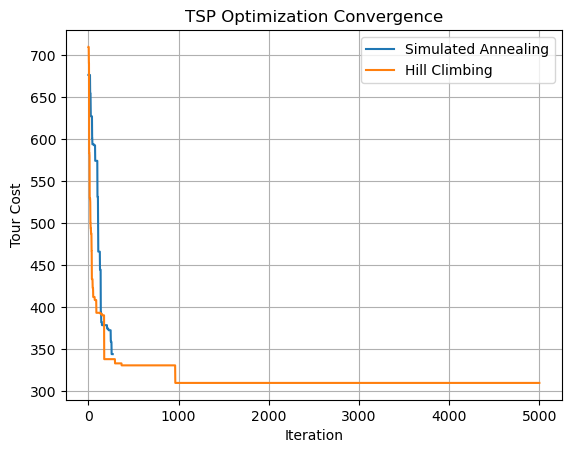

In [3]:
import random
import math
import matplotlib.pyplot as plt

# ---------------------------
# Generate cities
# ---------------------------
n_cities = 15
cities = [(random.randint(0,100), random.randint(0,100)) for _ in range(n_cities)]

def euclidean_distance(a,b):
    return math.sqrt((a[0]-b[0])**2 + (a[1]-b[1])**2)

# Precompute distance matrix
dist_matrix = [[0]*n_cities for _ in range(n_cities)]

for i in range(n_cities):
    for j in range(n_cities):
        dist_matrix[i][j] = euclidean_distance(cities[i], cities[j])


# ---------------------------
# Cost function
# ---------------------------
def tour_cost(tour):

    cost = 0

    for i in range(len(tour)-1):
        cost += dist_matrix[tour[i]][tour[i+1]]

    cost += dist_matrix[tour[-1]][tour[0]]

    return cost


# ---------------------------
# Neighbor function: 2-opt
# ---------------------------
def two_opt_swap(tour):

    i, j = sorted(random.sample(range(len(tour)),2))

    new_tour = tour[:]
    new_tour[i:j] = reversed(new_tour[i:j])

    return new_tour


# ---------------------------
# Simulated Annealing
# ---------------------------
def simulated_annealing(initial_tour, T0, alpha, max_iter, threshold):

    current = initial_tour[:]
    best = current[:]

    current_cost = tour_cost(current)
    best_cost = current_cost

    T = T0
    iteration = 0

    costs = []

    while T > threshold and iteration < max_iter:

        new_tour = two_opt_swap(current)
        new_cost = tour_cost(new_tour)

        delta = new_cost - current_cost

        if delta < 0:
            current = new_tour
            current_cost = new_cost
        else:
            prob = math.exp(-delta/T)
            if random.random() < prob:
                current = new_tour
                current_cost = new_cost

        if current_cost < best_cost:
            best = current[:]
            best_cost = current_cost

        costs.append(best_cost)

        T = alpha*T
        iteration += 1

    return best, best_cost, iteration, costs


# ---------------------------
# Hill Climbing
# ---------------------------
def hill_climbing(initial_tour, max_iter):

    current = initial_tour[:]
    current_cost = tour_cost(current)

    costs = []

    for i in range(max_iter):

        neighbor = two_opt_swap(current)
        neighbor_cost = tour_cost(neighbor)

        if neighbor_cost < current_cost:
            current = neighbor
            current_cost = neighbor_cost

        costs.append(current_cost)

    return current, current_cost, costs


# ---------------------------
# Run experiment
# ---------------------------

initial_tour = list(range(n_cities))
random.shuffle(initial_tour)

initial_cost = tour_cost(initial_tour)

print("Initial tour cost:", initial_cost)

sa_tour, sa_cost, sa_iter, sa_costs = simulated_annealing(
    initial_tour,
    T0=1000,
    alpha=0.95,
    max_iter=5000,
    threshold=0.001
)

hc_tour, hc_cost, hc_costs = hill_climbing(initial_tour,5000)

print("\nSimulated Annealing Final Cost:", sa_cost)
print("Total iterations:", sa_iter)

print("\nHill Climbing Final Cost:", hc_cost)


# ---------------------------
# Plot convergence
# ---------------------------

plt.plot(sa_costs,label="Simulated Annealing")
plt.plot(hc_costs,label="Hill Climbing")

plt.xlabel("Iteration")
plt.ylabel("Tour Cost")
plt.title("TSP Optimization Convergence")

plt.legend()
plt.grid()
plt.show()

# Task 4: Simulated Annealing for Continuous Function Optimization

Initial x: 0.8305410422185329
Initial value: 8.072762416454578

Simulated Annealing (Exponential) best value: -7.945666084638704
Simulated Annealing (Linear) best value: -7.945762325189498
Hill Climbing best value: -7.945823332385662


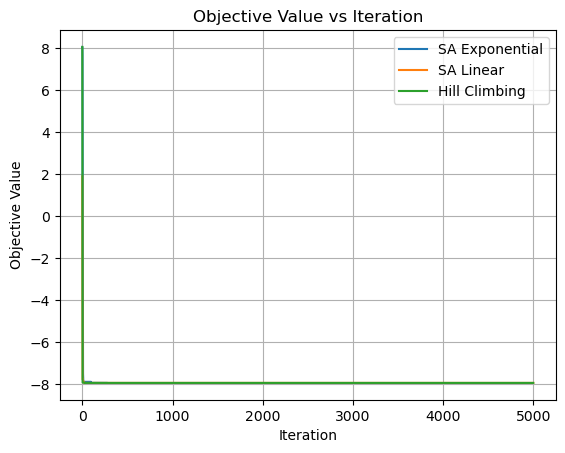

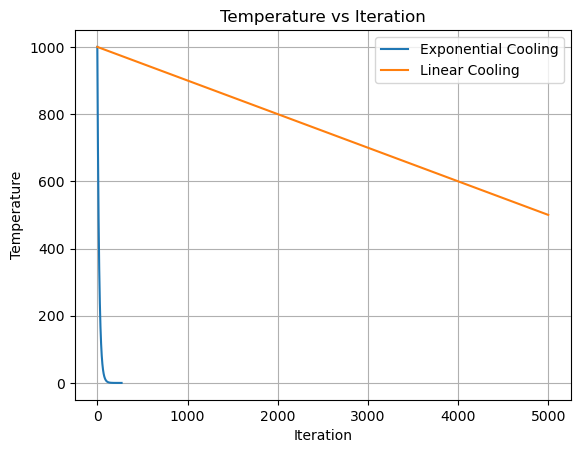

In [4]:
import math
import random
import matplotlib.pyplot as plt

# ---------------------------
# Function
# ---------------------------
def f(x):
    return x**2 + 10*math.sin(x)


# ---------------------------
# Neighbor function
# ---------------------------
def neighbor(x, step_size=1.0):

    new_x = x + random.uniform(-step_size, step_size)

    # keep inside bounds
    new_x = max(-10, min(10, new_x))

    return new_x


# ---------------------------
# Simulated Annealing
# ---------------------------
def simulated_annealing_continuous(x0, T0, alpha, max_iter,
                                   cooling='exponential',
                                   threshold=0.001):

    current = x0
    current_val = f(current)

    best_x = current
    best_val = current_val

    T = T0

    values = []
    temps = []

    for i in range(max_iter):

        if T < threshold:
            break

        new_x = neighbor(current)
        new_val = f(new_x)

        delta = new_val - current_val

        if delta < 0:
            current = new_x
            current_val = new_val
        else:
            prob = math.exp(-delta/T)
            if random.random() < prob:
                current = new_x
                current_val = new_val

        if current_val < best_val:
            best_x = current
            best_val = current_val

        values.append(best_val)
        temps.append(T)

        # cooling schedules
        if cooling == 'exponential':
            T = alpha*T
        elif cooling == 'linear':
            T = T - alpha

    return best_x, best_val, values, temps


# ---------------------------
# Hill Climbing
# ---------------------------
def hill_climbing_continuous(x0, max_iter):

    current = x0
    current_val = f(current)

    values = []

    for i in range(max_iter):

        new_x = neighbor(current)
        new_val = f(new_x)

        if new_val < current_val:
            current = new_x
            current_val = new_val

        values.append(current_val)

    return current, current_val, values


# ---------------------------
# Run experiment
# ---------------------------
x0 = random.uniform(-10,10)

print("Initial x:",x0)
print("Initial value:",f(x0))

sa_exp_x, sa_exp_val, sa_exp_vals, sa_exp_temp = simulated_annealing_continuous(
    x0, T0=1000, alpha=0.95, max_iter=5000, cooling='exponential'
)

sa_lin_x, sa_lin_val, sa_lin_vals, sa_lin_temp = simulated_annealing_continuous(
    x0, T0=1000, alpha=0.1, max_iter=5000, cooling='linear'
)

hc_x, hc_val, hc_vals = hill_climbing_continuous(x0,5000)

print("\nSimulated Annealing (Exponential) best value:",sa_exp_val)
print("Simulated Annealing (Linear) best value:",sa_lin_val)
print("Hill Climbing best value:",hc_val)


# ---------------------------
# Plot Objective vs Iteration
# ---------------------------
plt.plot(sa_exp_vals,label="SA Exponential")
plt.plot(sa_lin_vals,label="SA Linear")
plt.plot(hc_vals,label="Hill Climbing")

plt.xlabel("Iteration")
plt.ylabel("Objective Value")
plt.title("Objective Value vs Iteration")

plt.legend()
plt.grid()
plt.show()


# ---------------------------
# Plot Temperature vs Iteration
# ---------------------------
plt.plot(sa_exp_temp,label="Exponential Cooling")
plt.plot(sa_lin_temp,label="Linear Cooling")

plt.xlabel("Iteration")
plt.ylabel("Temperature")
plt.title("Temperature vs Iteration")

plt.legend()
plt.grid()
plt.show()